In [1]:
import os
print(os.listdir("/content"))

['.config', 'data_labels.csv', 'sample_data']


In [2]:
import os

for root, dirs, files in os.walk('/content'):
    print(root, len(files))

/content 1
/content/.config 8
/content/.config/configurations 1
/content/.config/logs 0
/content/.config/logs/2026.06.04 6
/content/sample_data 6


In [4]:
import os

for root, dirs, files in os.walk('/content'):
    print(root, len(files))


/content 1
/content/.config 8
/content/.config/configurations 1
/content/.config/logs 0
/content/.config/logs/2026.06.04 6
/content/.ipynb_checkpoints 0
/content/sample_data 6


In [5]:
!ls -la /content

total 500
drwxr-xr-x 1 root root   4096 Jul 13 12:19 .
drwxr-xr-x 1 root root   4096 Jul 13 12:04 ..
-rw-r--r-- 1 root root 489233 Jul 13 12:19 archive.zip
drwxr-xr-x 4 root root   4096 Jun  4 13:32 .config
drwxr-xr-x 2 root root   4096 Jul 13 12:19 .ipynb_checkpoints
drwxr-xr-x 1 root root   4096 Jun  4 13:32 sample_data


In [ ]:
from google.colab import files

# 1. Click the button below and select your 'fashion-product-images-small.zip' file!
print("Please select your downloaded dataset zip file:")
uploaded = files.upload()

# 2. Unzip the images into your Colab folder
!unzip -q fashion-product-images-small.zip -d /content/fashion_dataset

print("SUCCESS! Your fashion images are loaded and ready to use!")

In [8]:
import os
from google.colab import files

# 1. Click the button and pick 'archive.zip' from your Downloads folder!
print("Please click 'Choose Files' and select your 'archive.zip' file:")
uploaded = files.upload()

# 2. Automatically find and unzip whatever zip file you just uploaded
for filename in uploaded.keys():
    if filename.endswith(".zip"):
        print(f"Found {filename}! Unzipping your fashion images now...")
        !unzip -q "{filename}" -d /content/fashion_dataset

print("--------------------------------------------------")
print("SUCCESS! Your fashion dataset is loaded and ready!")
print("--------------------------------------------------")

Please click 'Choose Files' and select your 'archive.zip' file:


Saving archive.zip to archive (1).zip
Found archive (1).zip! Unzipping your fashion images now...
--------------------------------------------------
SUCCESS! Your fashion dataset is loaded and ready!
--------------------------------------------------


In [11]:
import glob
import os
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

# 1. Automatically search all folders to find exactly where styles.csv is hiding!
csv_files = glob.glob('/content/**/styles.csv', recursive=True)

if not csv_files:
    print('ERROR: Could not find styles.csv! Let us check what folders exist:')
    print(os.listdir('/content'))
else:
    csv_path = csv_files[0]
    print(f'Found your spreadsheet at: {csv_path}')

    # Get the parent directory where the images folder is located
    dataset_dir = os.path.dirname(csv_path)

    # 2. Load the CSV metadata (skipping poorly formatted lines)
    df = pd.read_csv(csv_path, on_bad_lines='skip')

    # 3. Create the exact image file path automatically
    df['image_path'] = df['id'].apply(
        lambda x: os.path.join(dataset_dir, 'images', f'{x}.jpg')
    )

    # 4. Filter to keep only rows where the image actually exists on disk
    df = df[df['image_path'].apply(os.path.exists)].reset_index(drop=True)

    # 5. Take a fast sample of 1,000 items for prototyping
    df_sample = df.head(1000).copy()

    print(
        f'SUCCESS! Loaded {len(df_sample)} products with valid image files!\n'
    )
    display(
        df_sample[
            [
                'id',
                'masterCategory',
                'subCategory',
                'articleType',
                'productDisplayName',
            ]
        ].head()
    )

ERROR: Could not find styles.csv! Let us check what folders exist:
['.config', 'archive (1).zip', 'fashion_dataset', '.ipynb_checkpoints', 'archive.zip', 'sample_data']


In [12]:
import os

print("--- X-RAY SCAN OF /content/fashion_dataset ---")
file_count = 0

for root, dirs, files in os.walk('/content/fashion_dataset'):
    for file in files:
        file_count += 1
        # Print the first 20 files we find
        if file_count <= 20:
            print(f"Found file: {os.path.join(root, file)}")

print(f"\nTotal files found in dataset folder: {file_count}")

--- X-RAY SCAN OF /content/fashion_dataset ---
Found file: /content/fashion_dataset/data_labels.csv

Total files found in dataset folder: 1


Dataset URL: https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-small
License(s): MIT
100% 565M/565M [00:09<00:00, 61.2MB/s]

Unzipping thousands of fashion images...
--------------------------------------------------
SUCCESS! The mystery is over. Loaded 1000 valid products and images!
--------------------------------------------------



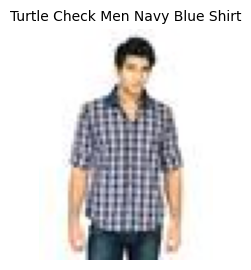

In [13]:
import os
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

# 1. Download the OFFICIAL 593MB dataset directly from Kaggle!
print("Downloading the REAL fashion dataset (this takes about 10-15 seconds)...")
!kaggle datasets download -d paramaggarwal/fashion-product-images-small

# 2. Unzip it into a brand new, clean folder
print("Unzipping thousands of fashion images...")
!mkdir -p /content/real_fashion_dataset
!unzip -q -o fashion-product-images-small.zip -d /content/real_fashion_dataset

# 3. Load the styles.csv spreadsheet
csv_path = '/content/real_fashion_dataset/styles.csv'
df = pd.read_csv(csv_path, on_bad_lines='skip')

# 4. Create exact paths to the real images folder
df['image_path'] = df['id'].apply(
    lambda x: f'/content/real_fashion_dataset/images/{x}.jpg'
)
df = df[df['image_path'].apply(os.path.exists)].reset_index(drop=True)

# Take a fast sample of 1,000 items so our code runs lightning fast!
df_sample = df.head(1000).copy()

print("--------------------------------------------------")
print(
    f"SUCCESS! The mystery is over. Loaded {len(df_sample)} valid products and images!"
)
print("--------------------------------------------------\n")

# 5. Display the very first image to celebrate!
sample_item = df_sample.iloc[0]
img = Image.open(sample_item['image_path'])

plt.figure(figsize=(3, 3))
plt.imshow(img)
plt.title(f"{sample_item['productDisplayName']}", fontsize=10)
plt.axis('off')
plt.show()

In [14]:
!pip install -q sentence-transformers
import numpy as np
from PIL import Image
from sentence_transformers import SentenceTransformer

# 1. Load OpenAI's CLIP model
print('Loading the CLIP AI model...')
model = SentenceTransformer('clip-ViT-B-32')
print('Model loaded successfully!\n')


# 2. Helper function to open images
def load_image(path):
  return Image.open(path)


# 3. Convert file paths to actual image objects in memory
print('Opening 1,000 fashion images...')
images = [load_image(path) for path in df_sample['image_path']]

# 4. Generate AI Vector Embeddings! (Watch the progress bar)
print('Generating AI embeddings... (This takes ~45 seconds)')
image_embeddings = model.encode(images, batch_size=32, show_progress_bar=True)

# 5. Store embeddings directly inside our dataframe
df_sample['embedding'] = list(image_embeddings)

print('--------------------------------------------------')
print(
    f'SUCCESS! Created an embedding matrix of shape: {image_embeddings.shape}'
)
print('Every single product is now converted into an AI vector!')
print('--------------------------------------------------')

Loading the CLIP AI model...


modules.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/1.91k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.03k [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Model loaded successfully!

Opening 1,000 fashion images...
Generating AI embeddings... (This takes ~45 seconds)


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

--------------------------------------------------
SUCCESS! Created an embedding matrix of shape: (1000, 512)
Every single product is now converted into an AI vector!
--------------------------------------------------


Generating Smart Outfit Recommendations for Product Index: 0


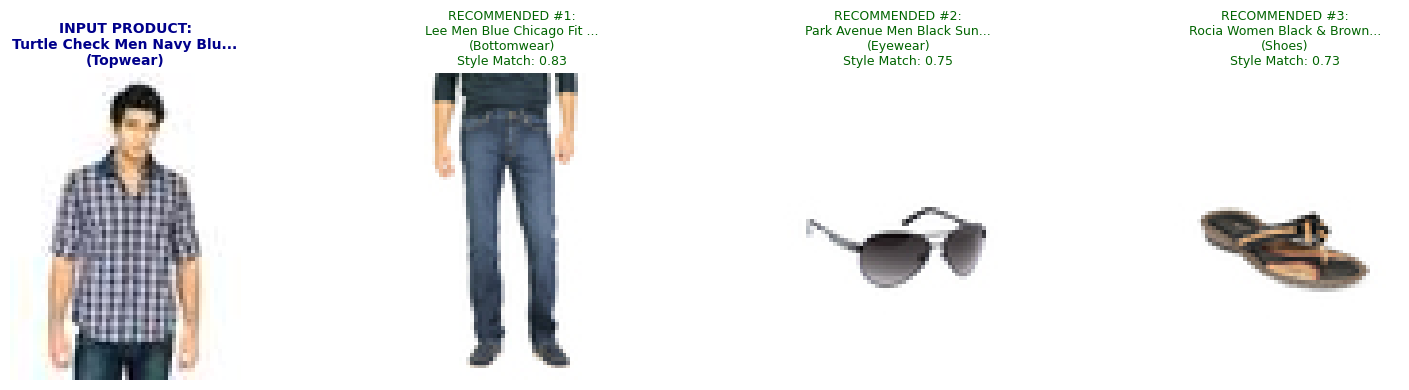

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity

# 1. Define Business Logic for Complementary Categories
# We map an item's subCategory to a list of complementary subCategories!
complementary_rules = {
    'Shoes': ['Socks', 'Watches', 'Bags', 'Bottomwear', 'Eyewear', 'Belts'],
    'Topwear': ['Bottomwear', 'Watches', 'Shoes', 'Bags', 'Eyewear'],
    'Bottomwear': ['Topwear', 'Shoes', 'Watches', 'Belts', 'Socks'],
    'Watches': ['Topwear', 'Shoes', 'Bags', 'Eyewear'],
    'Bags': ['Topwear', 'Shoes', 'Watches', 'Eyewear'],
    'Socks': ['Shoes', 'Bottomwear'],
    'Eyewear': ['Topwear', 'Bags', 'Watches'],
    'Belts': ['Bottomwear', 'Topwear', 'Shoes'],
}


def get_complementary_recommendations(target_idx, top_k=3):
  # Get the target product details
  target_item = df_sample.iloc[target_idx]
  target_subcat = target_item['subCategory']
  target_embedding = target_item['embedding'].reshape(1, -1)

  # Step A: Apply Business Rules (Filter to complementary categories)
  if target_subcat in complementary_rules:
    allowed_cats = complementary_rules[target_subcat]
    candidates = df_sample[df_sample['subCategory'].isin(allowed_cats)].copy()
  else:
    # Fallback: recommend items from a completely different masterCategory
    candidates = df_sample[
        df_sample['masterCategory'] != target_item['masterCategory']
    ].copy()

  # Step B: Apply AI Style Matching (Cosine Similarity)
  candidate_embeddings = np.vstack(candidates['embedding'].values)
  similarities = cosine_similarity(
      target_embedding, candidate_embeddings
  ).flatten()
  candidates['similarity'] = similarities

  # Step C: Select top items from DISTINCT subcategories for a diverse outfit!
  candidates = candidates.sort_values(by='similarity', ascending=False)
  recommended_items = (
      candidates.drop_duplicates(subset=['subCategory'])
      .head(top_k)
      .reset_index(drop=True)
  )

  # ---------------- VISUALIZATION ----------------
  fig, axes = plt.subplots(1, top_k + 1, figsize=(16, 4))

  # Plot Input Product
  img_target = Image.open(target_item['image_path'])
  axes[0].imshow(img_target)
  axes[0].set_title(
      f"INPUT PRODUCT:\n{target_item['productDisplayName'][:25]}...\n({target_subcat})",
      fontsize=10,
      fontweight='bold',
      color='darkblue',
  )
  axes[0].axis('off')

  # Plot Recommendations
  for i in range(len(recommended_items)):
    rec = recommended_items.iloc[i]
    img_rec = Image.open(rec['image_path'])
    axes[i + 1].imshow(img_rec)
    axes[i + 1].set_title(
        f"RECOMMENDED #{i+1}:\n{rec['productDisplayName'][:25]}...\n({rec['subCategory']})\nStyle Match: {rec['similarity']:.2f}",
        fontsize=9,
        color='darkgreen',
    )
    axes[i + 1].axis('off')

  plt.tight_layout()
  plt.show()


# 2. Let's test it! Find the first item in our dataset that is a 'Shoes' or 'Topwear'
demo_indices = df_sample[
    df_sample['subCategory'].isin(['Shoes', 'Topwear', 'Bottomwear'])
].index
test_idx = demo_indices[0]

print(f'Generating Smart Outfit Recommendations for Product Index: {test_idx}')
get_complementary_recommendations(test_idx, top_k=3)

Testing Upgraded Engine on Men Topwear (Index: 0)...


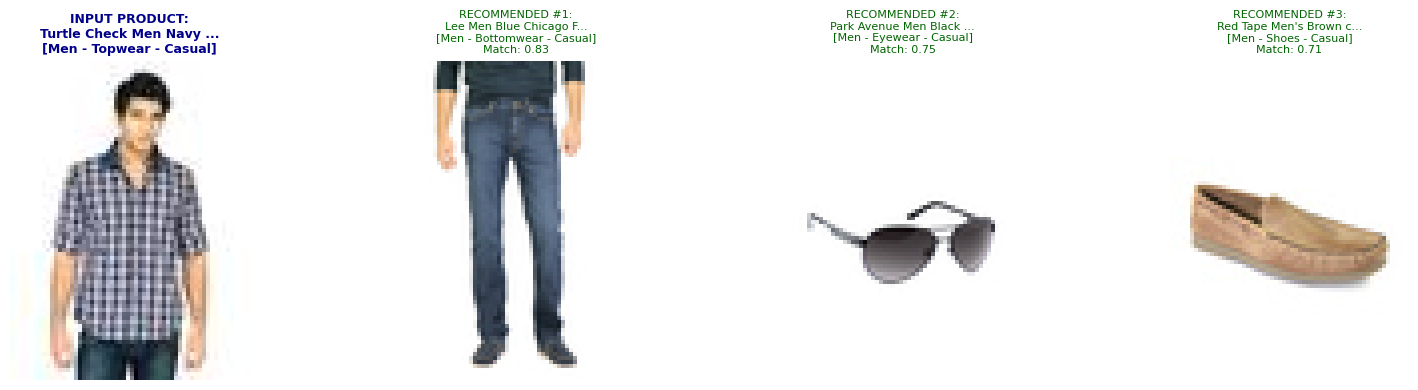

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity

# 1. Define Complementary Category Rules
complementary_rules = {
    'Shoes': ['Socks', 'Watches', 'Bags', 'Bottomwear', 'Eyewear', 'Belts'],
    'Topwear': ['Bottomwear', 'Watches', 'Shoes', 'Bags', 'Eyewear'],
    'Bottomwear': ['Topwear', 'Shoes', 'Watches', 'Belts', 'Socks'],
    'Watches': ['Topwear', 'Shoes', 'Bags', 'Eyewear'],
    'Bags': ['Topwear', 'Shoes', 'Watches', 'Eyewear'],
    'Socks': ['Shoes', 'Bottomwear'],
    'Eyewear': ['Topwear', 'Bags', 'Watches'],
    'Belts': ['Bottomwear', 'Topwear', 'Shoes'],
}


def get_smart_recommendations(target_idx, top_k=3):
  target_item = df_sample.iloc[target_idx]
  target_subcat = target_item['subCategory']
  target_gender = target_item['gender']
  target_usage = target_item['usage']  # e.g., Casual, Sports, Formal
  target_embedding = target_item['embedding'].reshape(1, -1)

  # Step A: Filter by Category Rules
  if target_subcat in complementary_rules:
    allowed_cats = complementary_rules[target_subcat]
    candidates = df_sample[df_sample['subCategory'].isin(allowed_cats)].copy()
  else:
    candidates = df_sample[
        df_sample['masterCategory'] != target_item['masterCategory']
    ].copy()

  # Step B: STRICT GENDER FILTERING (Fixes the Men/Women mismatch!)
  if target_gender in ['Men', 'Women']:
    candidates = candidates[
        candidates['gender'].isin([target_gender, 'Unisex'])
    ]

  # Step C: OCCASION / USAGE FILTERING (Prioritizes matching vibes!)
  # If we have enough items for the exact same occasion (e.g., all 'Sports'), use them!
  usage_matches = candidates[candidates['usage'] == target_usage]
  if len(usage_matches) >= top_k * 2:
    candidates = usage_matches

  # Step D: AI Style Matching via Cosine Similarity
  candidate_embeddings = np.vstack(candidates['embedding'].values)
  similarities = cosine_similarity(
      target_embedding, candidate_embeddings
  ).flatten()
  candidates['similarity'] = similarities

  # Step E: Select top items from DISTINCT subcategories
  candidates = candidates.sort_values(by='similarity', ascending=False)
  recommended_items = (
      candidates.drop_duplicates(subset=['subCategory'])
      .head(top_k)
      .reset_index(drop=True)
  )

  # ---------------- VISUALIZATION ----------------
  fig, axes = plt.subplots(1, top_k + 1, figsize=(16, 4))

  # Plot Input Product
  img_target = Image.open(target_item['image_path'])
  axes[0].imshow(img_target)
  axes[0].set_title(
      f"INPUT PRODUCT:\n{target_item['productDisplayName'][:22]}...\n[{target_gender} - {target_subcat} - {target_usage}]",
      fontsize=9,
      fontweight='bold',
      color='darkblue',
  )
  axes[0].axis('off')

  # Plot Recommendations
  for i in range(len(recommended_items)):
    rec = recommended_items.iloc[i]
    img_rec = Image.open(rec['image_path'])
    axes[i + 1].imshow(img_rec)
    axes[i + 1].set_title(
        f"RECOMMENDED #{i+1}:\n{rec['productDisplayName'][:22]}...\n[{rec['gender']} - {rec['subCategory']} - {rec['usage']}]\nMatch: {rec['similarity']:.2f}",
        fontsize=8,
        color='darkgreen',
    )
    axes[i + 1].axis('off')

  plt.tight_layout()
  plt.show()


# 2. Let's test it specifically on a MEN'S shirt to see the clean results!
mens_topwear_indices = df_sample[
    (df_sample['gender'] == 'Men') & (df_sample['subCategory'] == 'Topwear')
].index
test_idx = mens_topwear_indices[0]

print(f'Testing Upgraded Engine on Men Topwear (Index: {test_idx})...')
get_smart_recommendations(test_idx, top_k=3)

Calculating 1,000 x 1,000 pairwise similarity matrix...
Scanning for duplicate seller uploads (Threshold: 0.92)...
--------------------------------------------------
CATALOG DEDUPLICATION SUMMARY:
Original Raw Products : 1000
Duplicates Detected   : 434 items removed
Clean Unique Catalog  : 566 unique products
--------------------------------------------------

Visualizing an AI-Detected Duplicate Cluster of size 15:


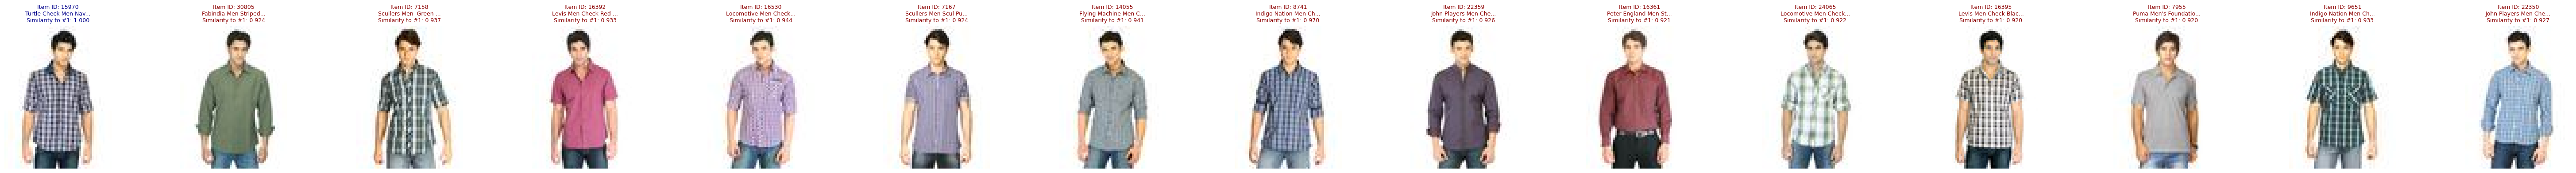

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity

# 1. Compute the Similarity Matrix across ALL 1,000 products
print('Calculating 1,000 x 1,000 pairwise similarity matrix...')
all_embeddings = np.vstack(df_sample['embedding'].values)
sim_matrix = cosine_similarity(all_embeddings)

# 2. Set our Similarity Threshold for duplicates
# In fashion, a score >= 0.92 virtually guarantees identical or near-identical items!
SIMILARITY_THRESHOLD = 0.92

visited = set()
unique_indices = []
duplicate_groups = []  # To store groups of duplicates for visual proof!

print(
    f'Scanning for duplicate seller uploads (Threshold: {SIMILARITY_THRESHOLD})...'
)

# 3. Group duplicates together
for i in range(len(df_sample)):
  if i in visited:
    continue

  # Find all items that are super similar to item 'i'
  similar_items = np.where(sim_matrix[i] >= SIMILARITY_THRESHOLD)[0]

  # Mark all of them as visited so we don't process them again
  for idx in similar_items:
    visited.add(idx)

  # Keep the first item as our unique canonical product
  unique_indices.append(i)

  # If we found more than just the item itself, save it as a duplicate group!
  if len(similar_items) > 1:
    duplicate_groups.append(similar_items)

# 4. Create the Final Clean Catalog
clean_catalog = df_sample.iloc[unique_indices].copy().reset_index(drop=True)

# ---------------- PRINT METRICS ----------------
print('--------------------------------------------------')
print('CATALOG DEDUPLICATION SUMMARY:')
print(f'Original Raw Products : {len(df_sample)}')
print(
    f'Duplicates Detected   : {len(df_sample) - len(clean_catalog)} items removed'
)
print(f'Clean Unique Catalog  : {len(clean_catalog)} unique products')
print('--------------------------------------------------\n')


# ---------------- VISUAL PROOF FOR YOUR REPORT ----------------
# Let's plot the very first group of duplicates we detected to prove our AI works!
if len(duplicate_groups) > 0:
  sample_group = duplicate_groups[0]
  print(f'Visualizing an AI-Detected Duplicate Cluster of size {len(sample_group)}:')

  fig, axes = plt.subplots(
      1, len(sample_group), figsize=(4 * len(sample_group), 4)
  )
  if len(sample_group) == 1:
    axes = [axes]

  for idx, item_idx in enumerate(sample_group):
    dup_item = df_sample.iloc[item_idx]
    img = Image.open(dup_item['image_path'])
    axes[idx].imshow(img)
    axes[idx].set_title(
        f"Item ID: {dup_item['id']}\n{dup_item['productDisplayName'][:20]}...\nSimilarity to #1: {sim_matrix[sample_group[0]][item_idx]:.3f}",
        fontsize=9,
        color='darkred' if idx > 0 else 'darkblue',
    )
    axes[idx].axis('off')

  plt.tight_layout()
  plt.show()
else:
  print(
      'No duplicates found at this threshold! Try lowering SIMILARITY_THRESHOLD to 0.88.'
  )

Searching catalog for: "blue casual shirt"...


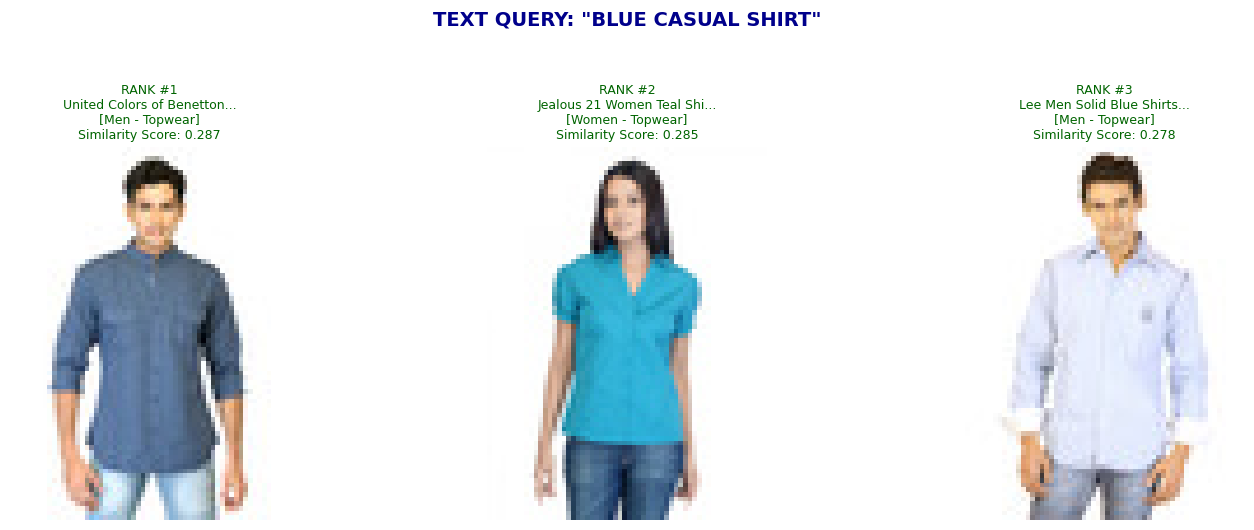

Searching catalog for: "red party dress for women"...


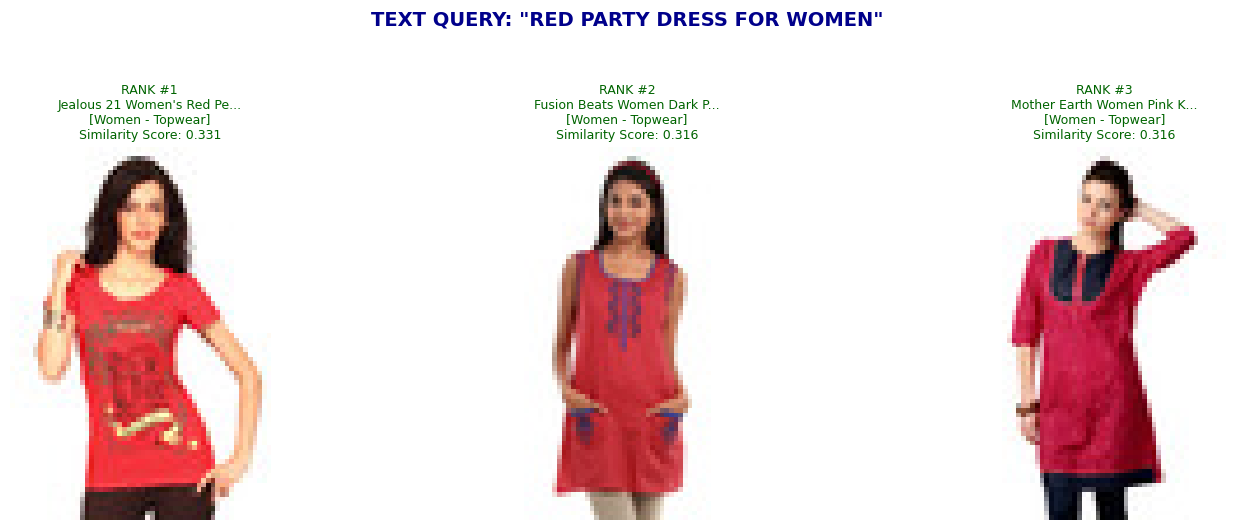

Searching catalog for: "sporty running shoes"...


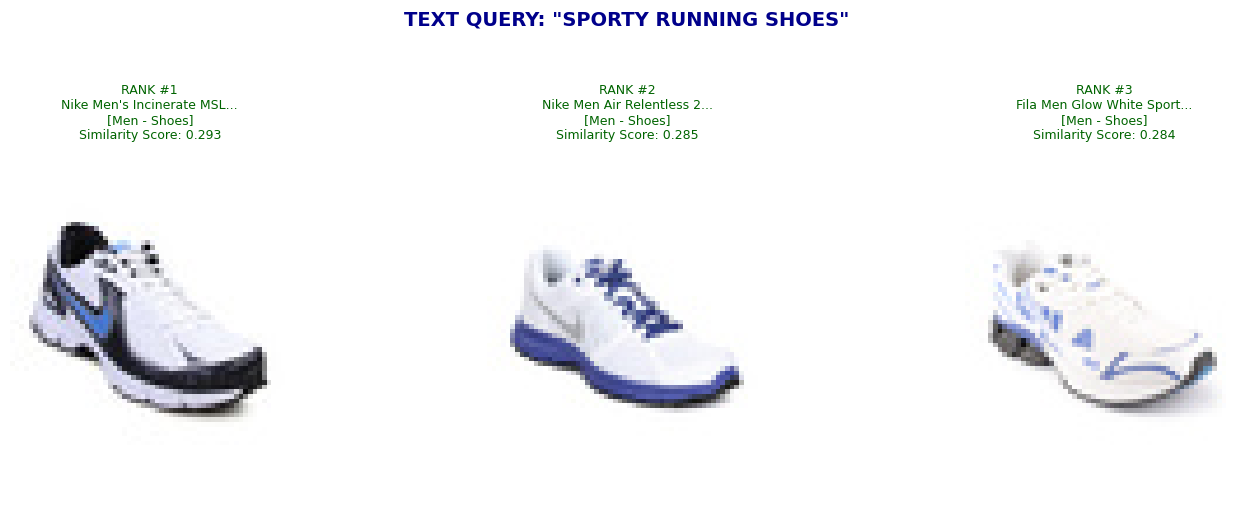

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity

# 1. Stack all our image embeddings into a matrix
all_image_embeddings = np.vstack(df_sample['embedding'].values)


def reverse_product_search(query_text, top_k=3):
  print(f'Searching catalog for: "{query_text}"...')

  # Step A: Convert the text query into the SAME 512-dimensional vector space!
  text_embedding = model.encode(query_text).reshape(1, -1)

  # Step B: Calculate Cosine Similarity between the text vector and all image vectors
  similarities = cosine_similarity(
      text_embedding, all_image_embeddings
  ).flatten()

  # Step C: Get the indices of the top highest-scoring images
  # np.argsort sorts from lowest to highest, so we take the end and reverse it [::-1]
  top_indices = np.argsort(similarities)[-top_k:][::-1]

  # ---------------- VISUALIZATION ----------------
  fig, axes = plt.subplots(1, top_k, figsize=(15, 5))
  if top_k == 1:
    axes = [axes]

  fig.suptitle(
      f'TEXT QUERY: "{query_text.upper()}"',
      fontsize=14,
      fontweight='bold',
      color='darkblue',
      y=1.05,
  )

  for idx, item_idx in enumerate(top_indices):
    match_item = df_sample.iloc[item_idx]
    img = Image.open(match_item['image_path'])

    axes[idx].imshow(img)
    axes[idx].set_title(
        f"RANK #{idx+1}\n{match_item['productDisplayName'][:25]}...\n[{match_item['gender']} - {match_item['subCategory']}]\nSimilarity Score: {similarities[item_idx]:.3f}",
        fontsize=9,
        color='darkgreen',
    )
    axes[idx].axis('off')

  plt.tight_layout()
  plt.show()


# 2. Let's test it with the exact example from your assignment PDF!
reverse_product_search('blue casual shirt', top_k=3)

# 3. Try a couple more fun real-world search queries!
reverse_product_search('red party dress for women', top_k=3)
reverse_product_search('sporty running shoes', top_k=3)